# Exercise 4

## Imports

In [73]:
import math
from enum import Enum
from pathlib import Path
from typing import Dict, Optional

import librosa
import numpy as np
import pandas as pd
from pandas import DataFrame


import seaborn as sns
import matplotlib.pyplot as plt

## Constants

In [74]:
current_dir = Path.cwd()

# Music file
rock_audiofile_path = current_dir.joinpath("data", "rock.mp3")


class FeatureType(Enum):
    SPECTRAL_CENTROID = "spectral_centroid"
    ZERO_CROSSING_RATE = "zero_crossing_rate"
    ROOT_MEAN_SQUARED_ENERGY = "root_mean_squared_energy"

## Exercise 1

Load the file rock.mp3 from the week 2 exercises in Python and extract the following features with
librosa, once with a frame length of 512 and once with 760:
- Spectral centroid
- Zero-crossing rate
- Root mean squared energy (RMS)

See https://librosa.org/doc/latest/feature.html for documentation on how to extract the features.

In [75]:
def get_column_name(feature_type: FeatureType, frame_length: int) -> str:
    return f"{feature_type.value}-{frame_length}"


def extract_feature(feature_type: FeatureType, y: np.ndarray, sr: int, frame_length: int, hop_length: int) -> pd.Series:
    if feature_type is FeatureType.SPECTRAL_CENTROID:
        features = librosa.feature.spectral_centroid(y=y,
                                                     sr=sr,
                                                     n_fft=frame_length,
                                                     hop_length=hop_length, )
    elif feature_type is FeatureType.ZERO_CROSSING_RATE:
        features = librosa.feature.zero_crossing_rate(y=y,
                                                      hop_length=frame_length,
                                                      frame_length=hop_length, )
    elif feature_type is FeatureType.ROOT_MEAN_SQUARED_ENERGY:
        features = librosa.feature.rms(y=y,
                                       frame_length=frame_length,
                                       hop_length=hop_length, )
    else:
        raise ValueError(f"Unknown feature type: {feature_type}")

    return pd.Series(features.flatten(), name=get_column_name(feature_type, frame_length))


# Load audio file
y, sr = librosa.load(rock_audiofile_path)
# y -> audio time series
# sr -> sampling rate
n_samples = len(y)
print(f"n samples = {n_samples}")

# Feature dataframe
features_df = DataFrame()
feature_window_length_dict = {}

frame_lengths = [512, 760]
for frame_length in frame_lengths:
    print(f"Extracting features with frame length: {frame_length}")

    hop_length = frame_length  # Assuming no overlap

    for feature_type in FeatureType:
        new_feature_series = extract_feature(feature_type, y, sr, frame_length, hop_length)
        print(new_feature_series.shape)

        features_df = pd.concat([features_df, new_feature_series], axis=1)
        feature_window_length_dict[new_feature_series.name] = frame_length

print(features_df)
print(feature_window_length_dict)

n samples = 5003136
Extracting features with frame length: 512
(9772,)
(9772,)
(9772,)
Extracting features with frame length: 760
(6584,)
(6584,)
(6584,)
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6231.235766                0.000000   
3               5536.693649                0.000000   
4               4711.469364                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760  \
0                     0.000000e+00               0.000000   
1                     0.000000e+00            7044.025098   
2 

In [76]:
# TODO: visualize data
#  create view of first few frames comparing feature values extracted with different window sizes (like in slide 18)

## Exercise 2

Given the features from Exercise 1, calculate a harmonised feature matrix for all six feature vectors.
The features should be harmonised to the frame length of fmin = 512.
First, use the harmonisation method shown on slide 18 and 19 of the lecture “Feature Processing and
Selection”.
Then, do the same by using a weighted average method in which features of adjacent frames are
weighted by their overlap ratio with the new frame.

In [77]:
def get_min_feature_length(feature_window_lengths: Dict[str, int]) -> int:
    return min(feature_window_lengths.values())


class HarmonizationMethod(Enum):
    SELECTION = "selection"
    AVERAGE = "average"


def harmonization_matrix(df: DataFrame, feature_window_lengths: Dict[str, int], total_samples: int,
                         harmonization_method: HarmonizationMethod = HarmonizationMethod.SELECTION,
                         min_feature_length: Optional[int] = None) -> DataFrame:
    """

    :param df: multiple series corresponding to different features.
        Can have trailing Nands.
        It is also assumed that each feature processes all samples.
    :param feature_window_lengths:
    :param min_feature_length:
    :return:
    """
    if min_feature_length is None:
        min_feature_length = get_min_feature_length(feature_window_lengths)

    num_windows = math.ceil(total_samples / min_feature_length)

    hm_df = pd.DataFrame()
    for series_name in df:
        window_length = feature_window_lengths[series_name]
        if window_length > min_feature_length:
            hf = []
            for w in range(num_windows):
                prev_opt_idx = (min_feature_length * (w - 1) // window_length) + 1
                next_opt_idx = prev_opt_idx + 1

                a = min_feature_length * (w - 1)
                b = window_length * prev_opt_idx
                c = min_feature_length * w

                w_first_len = b - a
                w_second_len = c - b

                if harmonization_method is HarmonizationMethod.SELECTION:
                    hf.append(df[series_name][prev_opt_idx]) if w_first_len > w_second_len else hf.append(
                        df[series_name][next_opt_idx])
                elif harmonization_method is HarmonizationMethod.AVERAGE:
                    hf.append((df[series_name][prev_opt_idx] * w_first_len + df[series_name][
                        next_opt_idx] * w_second_len) / min_feature_length)
            hm_df[series_name] = pd.Series(hf)
        else:
            hm_df[series_name] = df[series_name].copy()

    return hm_df, min_feature_length

## 2.1 - Harmonisation of feature matrix 1: SELECTION

In [78]:
hm1_df, min_feature_length = harmonization_matrix(features_df, feature_window_length_dict, n_samples,
                                                  HarmonizationMethod.SELECTION)
print(f"min_feature_length: {min_feature_length}")
print(hm1_df)

min_feature_length: 512
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6231.235766                0.000000   
3               5536.693649                0.000000   
4               4711.469364                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760  \
0                     0.000000e+00               0.000000   
1                     0.000000e+00            7044.025098   
2                     1.631707e-22            5440.669694   
3                     4.867558e-13            5440.669694   
4         

In [79]:
# Todo, visualize results !

## 2.2 - Harmonisation of feature matrix 2: AVERAGE

In [80]:
hm2_df, min_feature_length = harmonization_matrix(features_df, feature_window_length_dict, n_samples,
                                                  HarmonizationMethod.AVERAGE)
print(f"min_feature_length: {min_feature_length}")
print(hm2_df)

min_feature_length: 512
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6231.235766                0.000000   
3               5536.693649                0.000000   
4               4711.469364                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760  \
0                     0.000000e+00               0.000000   
1                     0.000000e+00            7820.650372   
2                     1.631707e-22            6217.294968   
3                     4.867558e-13            5395.565208   
4         

In [81]:
# Todo, visualize results !

In [82]:
# Todo, visualize comparison of original, result1, result 2 (per feature?)

## Exercise 3

For each of three feature types, calculate the correlation between the features with frame length 512
from Exercise 1 and the harmonised features with original frame length 760.
Which harmonisation method achieves higher correlation with the extracted features?

First Correlation Matrix 

                              spectral_centroid-512  zero_crossing_rate-512  \
spectral_centroid-512                      1.000000                0.779382   
zero_crossing_rate-512                     0.779382                1.000000   
root_mean_squared_energy-512              -0.218181               -0.426609   
spectral_centroid-760                      0.763305                0.669234   
zero_crossing_rate-760                     0.641338                0.830891   
root_mean_squared_energy-760              -0.032010               -0.237143   

                              root_mean_squared_energy-512  \
spectral_centroid-512                            -0.218181   
zero_crossing_rate-512                           -0.426609   
root_mean_squared_energy-512                      1.000000   
spectral_centroid-760                            -0.159653   
zero_crossing_rate-760                           -0.330279   
root_mean_squared_energy-760                   

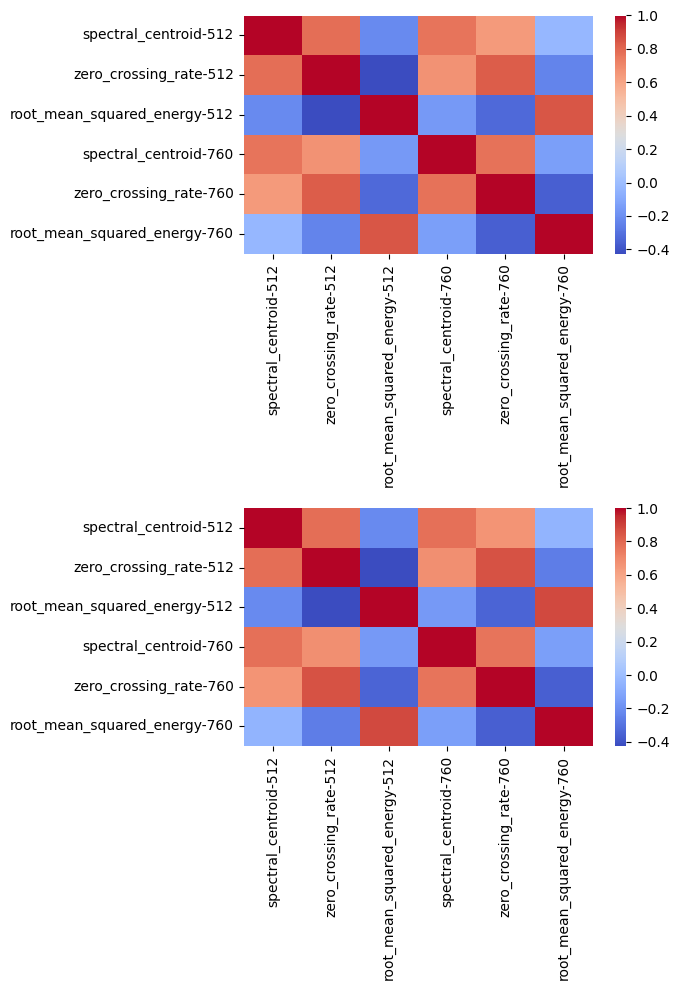

In [ ]:
#get features with length 512
features_512 = [x for x in features_df if "512" in x]
#create correlation matrix for them



#get features with length 760 from both harmon. matrix
hm1_760_feats = [x for x in hm1_df if "760" in x]

hm2_760_feats = [x for x in hm2_df if "760" in x]




features_512_df = features_df[features]
features_760_hm1_df = hm1_df[hm1_760_feats]
features_760_hm2_df = hm2_df[hm2_760_feats]


"""
#DEBUGGING
print("!!!!!!!!!!!!!!!\n")

print(features_760_hm1_df)


print("!!!!!!!!!!!!!!!\n")


print(features_760_hm2_df)


print("!!!!!!!!!!!!!!!\n")
"""


corr_df1 = pd.concat([features_512_df,features_760_hm1_df],axis=1,join="inner")

corr_df2 = pd.concat([features_512_df,features_760_hm2_df],axis=1,join="inner")

cor_mat1 = corr_df1.corr()

cor_mat2 = corr_df2.corr()


"""
#DEBUGGING
print("!!!!!!!!!!!!!!!\n")

print(corr_df1)


print("!!!!!!!!!!!!!!!\n")


print(corr_df2)


print("!!!!!!!!!!!!!!!\n")
"""


print("First Correlation Matrix \n")

print(cor_mat1)

print("\n")

print("Second Correlation Matrix \n")

print(cor_mat2)

print("\n")


#COMPARE MATRIZES
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 10))


sns.heatmap(cor_mat1,ax=axes[0],cmap="coolwarm")
sns.heatmap(cor_mat2,ax=axes[1],cmap="coolwarm")

plt.tight_layout()



### Plots

Plotting Exercise 1: Original Features...


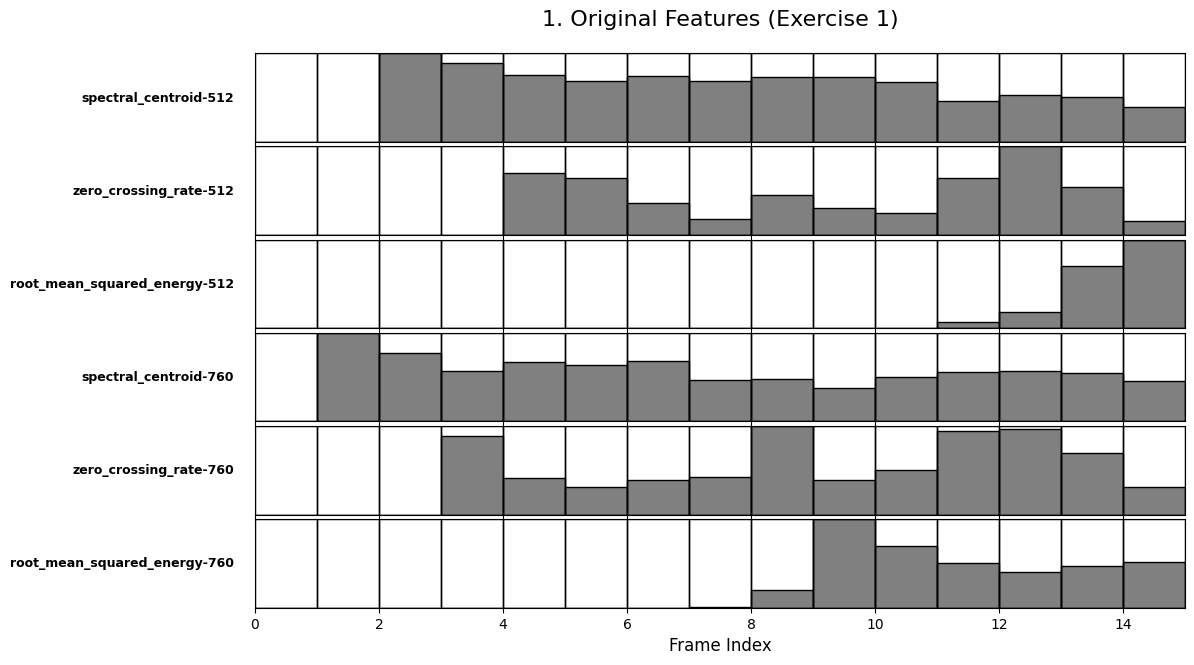


Plotting Exercise 2.1: Harmonized (Selection)...


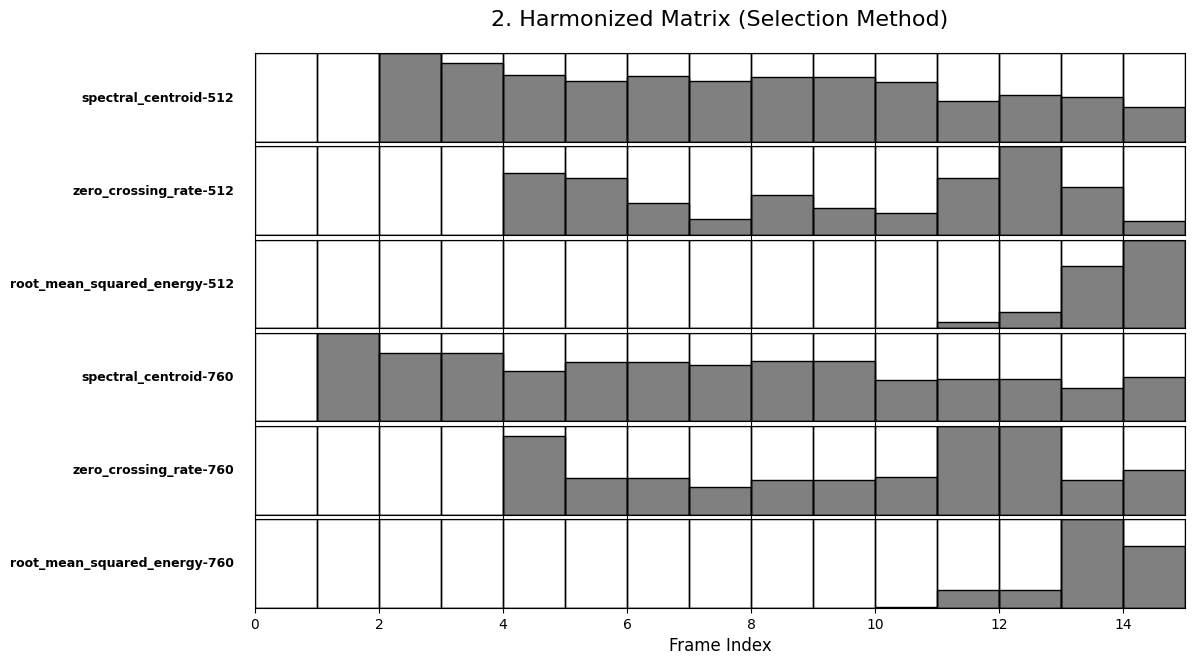


Plotting Exercise 2.2: Harmonized (Average)...


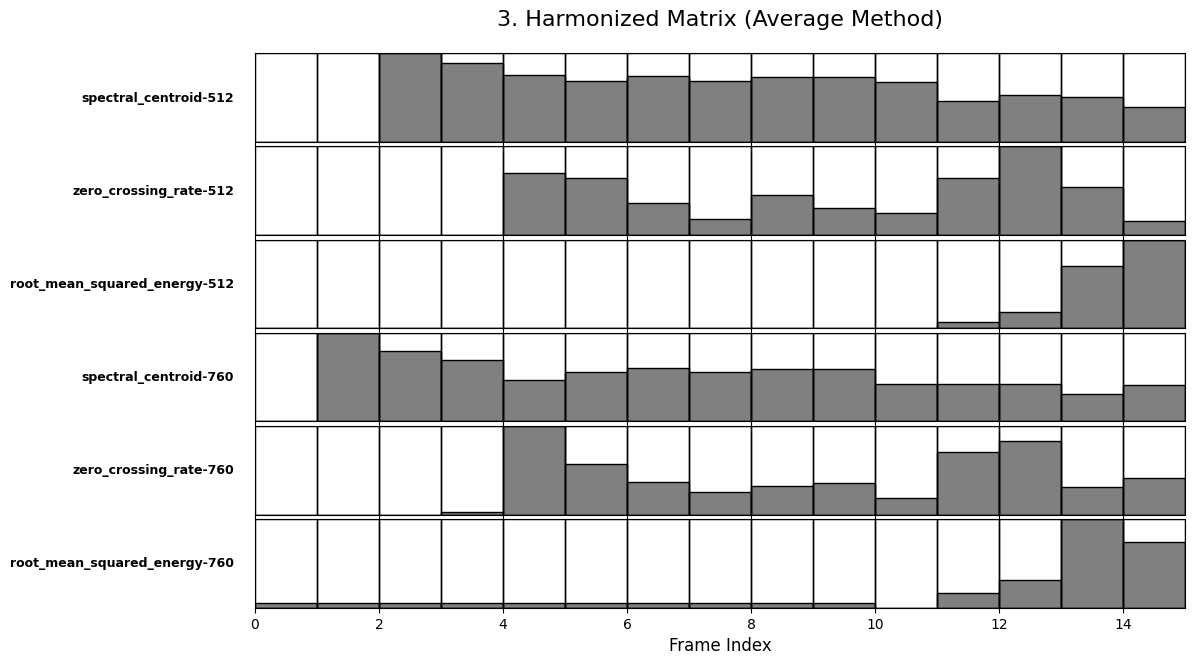

In [117]:

import matplotlib.patches as patches


def plot_feature_grid(df, title, n_frames=15):
    """
    Visualisiert die Features eines DataFrames als Block-Raster.
    """
    # Falls der DataFrame leer ist oder nicht existiert, abbrechen
    if df is None or df.empty:
        print(f"Skipping {title}: DataFrame is empty or None.")
        return

    feature_names = df.columns.tolist()
    
    # Nur die ersten n_frames betrachten
    subset = df.iloc[:n_frames].copy()

    # Normalisierung (Min-Max) pro Feature, damit alle in 0-1 passen
    # (Verhindert, dass Spectral Centroid die Skala sprengt)
    subset_norm = (subset - subset.min()) / (subset.max() - subset.min())
    
    # In Matrix umwandeln für Plotting (Zeilen = Features)
    data_matrix = subset_norm.T.values
    
    # Plot initialisieren
    # Höhe dynamisch anpassen je nach Anzahl der Features
    fig, axes = plt.subplots(nrows=len(feature_names), ncols=1, sharex=True, figsize=(12, len(feature_names) * 1.2))
    plt.subplots_adjust(hspace=0.05) # Kein Abstand zwischen den Zeilen
    
    x = np.arange(n_frames)
    
    for i, ax in enumerate(axes):
        vals = data_matrix[i]
        col_name = feature_names[i]
        
        # 1. Graue Balken zeichnen (valid_mask filtert NaNs für den bar-plot)
        valid_mask = ~np.isnan(vals)
        ax.bar(x[valid_mask], vals[valid_mask], width=1.0, align='edge', color='#808080', edgecolor='black', linewidth=1)
        
        # 2. Gitter-Rahmen über ALLES zeichnen (auch über leere/NaN Stellen)
        for step in x:
            # Rechteck von (step, 0) mit Breite 1 und Höhe 1
            rect = patches.Rectangle((step, 0), 1, 1, linewidth=1, edgecolor='black', facecolor='none')
            ax.add_patch(rect)
            
        # 3. Beschriftung und Achsen
        # Name linksbündig an die Achse
        ax.set_ylabel(col_name, rotation=0, labelpad=15, va='center', ha='right', fontsize=9, fontweight='bold')
        
        ax.set_yticks([]) # Keine Y-Werte anzeigen (da normalisiert)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, n_frames)
        
        # Titel nur über dem ersten Subplot
        if i == 0:
            ax.set_title(title, fontsize=16, pad=20)

        # 4. NaN explizit markieren
        if np.isnan(vals).any():
             for j, v in enumerate(vals):
                 if np.isnan(v):
                     # "NaN" Text in das leere Kästchen schreiben
                     ax.text(j + 0.5, 0.5, 'NaN', ha='center', va='center', fontsize=8, color='red', fontweight='bold')

    plt.xlabel("Frame Index", fontsize=12)
    plt.show()

# ==========================================
# AUSFÜHRUNG DER VISUALISIERUNGEN
# ==========================================

# 1. Original Features (Aufgabe 1)
if 'features_df' in locals():
    print("Plotting Exercise 1: Original Features...")
    plot_feature_grid(features_df, "1. Original Features (Exercise 1)", n_frames=15)
else:
    print("features_df nicht gefunden.")

# 2. Harmonisierte Matrix 1 - Selection (Aufgabe 2.1)
if 'hm1_df' in locals():
    print("\nPlotting Exercise 2.1: Harmonized (Selection)...")
    plot_feature_grid(hm1_df, "2. Harmonized Matrix (Selection Method)", n_frames=15)
else:
    print("hm1_df nicht gefunden.")

# 3. Harmonisierte Matrix 2 - Average (Aufgabe 2.2)
if 'hm2_df' in locals():
    print("\nPlotting Exercise 2.2: Harmonized (Average)...")
    plot_feature_grid(hm2_df, "3. Harmonized Matrix (Average Method)", n_frames=15)
else:
    print("hm2_df nicht gefunden.")